# Fig 5b - Systema Correlation across active-learning rounds

This notebook compares the same acquisition strategies across four methods. Each panel shows the mean `systema_correlation` across the available perturbation datasets at active-learning rounds 1-4.

In [16]:
# Cell 1 - imports, Nature rcParams, and export helper
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "font.size": 7,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.7,
    "legend.frameon": True,
})


def save_pub_py(fig, stem, dpi=600):
    """Save a figure as editable SVG and raster PNG.

    Args:
        fig: Matplotlib figure to save.
        stem: Output path without a file extension.
        dpi: Resolution of the PNG export.
    """
    Path(stem).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{stem}.svg", bbox_inches="tight")
    fig.savefig(f"{stem}.png", dpi=dpi, bbox_inches="tight")
    print(f"saved -> {stem}.svg / {stem}.png")

In [17]:
# Cell 2 - parameters (edit this cell)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "results").is_dir():
    REPO_ROOT = Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd()
RESULTS_DIR = REPO_ROOT / "results" / "active_learning"
OUT_STEM = REPO_ROOT / "figure" / "fig5b" / "fig5b_systema_correlation_all_methods"

METHODS = ["GenePert", "scLambda", "PRESAGE", "Biolord"]
METHOD_TITLES = {method: method for method in METHODS}

SEED_REP = "56_3"
REPEATS = None  # Use all available repeats; set to [0] to reproduce a single repeat.
METRIC = "systema_correlation"
GENE = "all"
SET_NAME = "test"
CONTEXTS = [
    "replogle_rpe1_essential_rpe1",
    "replogle_k562_essential_k562",
    "nadig_jurkat_essential_jurkat",
    "nadig_hepg2_essential_hepg2",
]

ROUND_BUDGETS = [10, 30, 50, 80]
ROUND_LABELS = [1, 2, 3, 4]
STRATEGY_ORDER = [
    "random_sampling",
    "diversity_sampling",
    "representative_sampling",
    "magnitude_sampling",
    "outlier_sampling",
    "typical_sampling",
]
STRATEGY_LABELS = {
    "random_sampling": "Random",
    "diversity_sampling": "Diversity",
    "representative_sampling": "Representative",
    "magnitude_sampling": "Magnitude",
    "outlier_sampling": "Outlier",
    "typical_sampling": "Typical",
}
# High-saturation red/blue palette: neutral Random, red coverage, and blue Top-K.
STRATEGY_FAMILY = {
    "random_sampling": "Random",
    "diversity_sampling": "Coverage",
    "representative_sampling": "Coverage",
    "magnitude_sampling": "Top-K",
    "outlier_sampling": "Top-K",
    "typical_sampling": "Top-K",
}
STRATEGY_COLORS = {
    "random_sampling":         "#7F7F7F",
    "diversity_sampling":      "#F04438",
    "representative_sampling": "#B2182B",
    "magnitude_sampling":      "#4393C3",
    "outlier_sampling":        "#2166AC",
    "typical_sampling":        "#053061",
}

CONTEXT_LABELS = {
    "nadig_hepg2_essential_hepg2": "HepG2",
    "nadig_jurkat_essential_jurkat": "Jurkat",
    "replogle_k562_essential_k562": "K562",
    "replogle_rpe1_essential_rpe1": "RPE1",
}

# Layout controls for the 4-by-4 method-by-context panel.
FIGSIZE = (15, 8.0)
PANEL_TITLE_SIZE = 10
AXIS_LABEL_SIZE = 10
TICK_LABEL_SIZE = 8
ROW_SPACING = 0.28
COLUMN_SPACING = 0.16
BOTTOM_MARGIN = 0.16
Y_LIM = (0.0, None)
Y_TICKS = [0.0, 0.2, 0.4, 0.6]
LEGEND_NCOL = 3

In [18]:
# Cell 3 - load one method/context panel at a time
def snap_to_levels(values, levels):
    """Map raw budgets to nominal budgets within a relative tolerance.

    Args:
        values: Raw budget values.
        levels: Nominal budget levels.

    Returns:
        Mapping from each raw value to a nominal level or None.
    """
    levels = sorted(levels)
    snapped = {}
    for value in values:
        nearest = min(levels, key=lambda level: abs(value - level))
        tolerance = max(0.3, 0.15 * nearest)
        snapped[value] = nearest if abs(value - nearest) <= tolerance else None
    return snapped


def load_context_curve(context, method, strategy):
    """Load one strategy curve for one context and method.

    Args:
        context: Perturbation context directory name.
        method: Model or prediction method directory name.
        strategy: Active-learning strategy directory name.

    Returns:
        Mapping from nominal budget to the selected metric, or None if missing.
    """
    path = RESULTS_DIR / context / method / f"{strategy}_{SEED_REP}" / "achievement_summary_rebuilt.csv"
    if not path.exists():
        return None
    frame = pd.read_csv(path)
    selected = frame[
        (frame["metric_name"] == METRIC)
        & (frame["gene"] == GENE)
        & (frame["set"] == SET_NAME)
    ].copy()
    if REPEATS is not None:
        selected = selected[selected["repeat"].isin(REPEATS)]
    if selected.empty:
        return None
    selected["budget"] = selected["x"].map(
        snap_to_levels(selected["x"].dropna().unique(), ROUND_BUDGETS)
    )
    selected = selected[selected["budget"].notna()]
    summary = selected.groupby("budget")["value"].agg(
        mean="mean",
        std=lambda values: values.std(ddof=1),
        n="count",
    )
    return {
        budget: {
            "mean": summary.loc[budget, "mean"] if budget in summary.index else np.nan,
            "std": summary.loc[budget, "std"] if budget in summary.index else 0.0,
            "n": summary.loc[budget, "n"] if budget in summary.index else 0,
        }
        for budget in ROUND_BUDGETS
    }


def load_method_context(method, context):
    """Load all strategy curves for one method and context.

    Args:
        method: Model or prediction method to load.
        context: Perturbation context to load.

    Returns:
        Mapping from strategy to values, standard deviations, and sample counts.
    """
    curves = {}
    for strategy in STRATEGY_ORDER:
        curve = load_context_curve(context, method, strategy)
        if curve is None:
            continue
        values = np.array([curve[budget]["mean"] for budget in ROUND_BUDGETS], dtype=float)
        errors = np.nan_to_num(
            np.array([curve[budget]["std"] for budget in ROUND_BUDGETS], dtype=float),
            nan=0.0,
        )
        n = np.array([curve[budget]["n"] for budget in ROUND_BUDGETS], dtype=int)
        curves[strategy] = {
            "mean": values,
            "std": errors,
            "n": n,
        }
        print(f"{method:10s} / {CONTEXT_LABELS[context]:6s} / {strategy:24s}")
    return curves

all_curves = {
    method: {context: load_method_context(method, context) for context in CONTEXTS}
    for method in METHODS
}

GenePert   / RPE1   / random_sampling         
GenePert   / RPE1   / diversity_sampling      
GenePert   / RPE1   / representative_sampling 
GenePert   / RPE1   / magnitude_sampling      
GenePert   / RPE1   / outlier_sampling        
GenePert   / RPE1   / typical_sampling        
GenePert   / K562   / random_sampling         
GenePert   / K562   / diversity_sampling      
GenePert   / K562   / representative_sampling 
GenePert   / K562   / magnitude_sampling      
GenePert   / K562   / outlier_sampling        
GenePert   / K562   / typical_sampling        
GenePert   / Jurkat / random_sampling         
GenePert   / Jurkat / diversity_sampling      
GenePert   / Jurkat / representative_sampling 
GenePert   / Jurkat / magnitude_sampling      
GenePert   / Jurkat / outlier_sampling        
GenePert   / Jurkat / typical_sampling        
GenePert   / HepG2  / random_sampling         
GenePert   / HepG2  / diversity_sampling      
GenePert   / HepG2  / representative_sampling 
GenePert   / 

saved -> figures/fig5b_pcc_specificity_all_methods.svg / figures/fig5b_pcc_specificity_all_methods.png


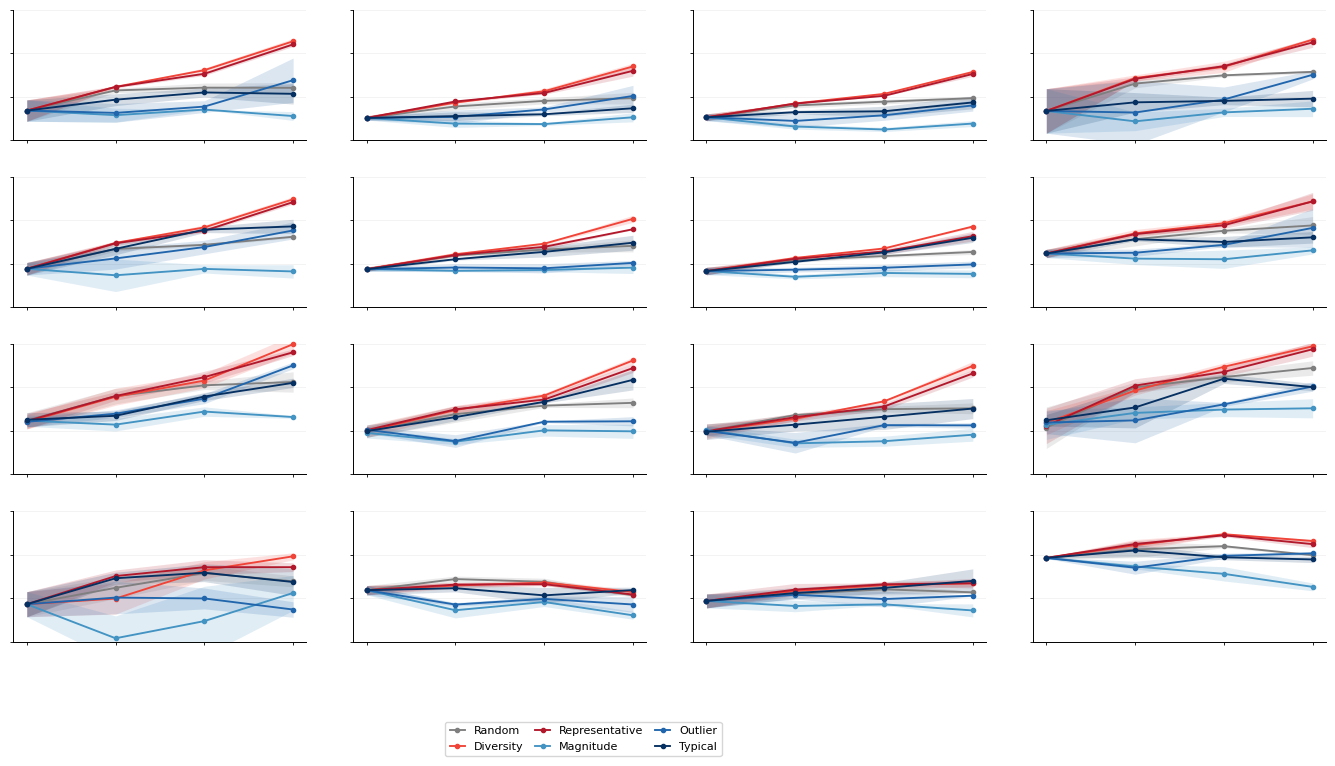

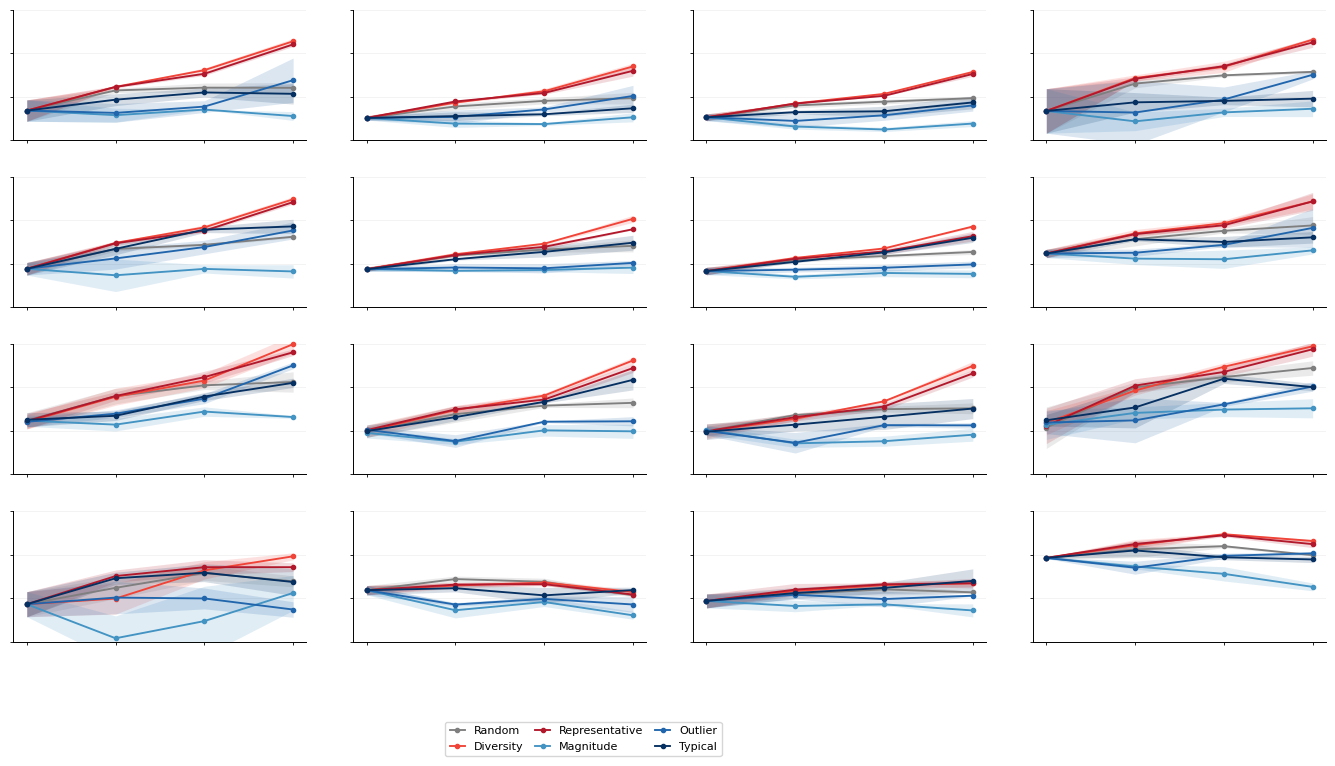

In [21]:
# Cell 4 - draw and export the combined method-by-context figure
def draw_panel(axis, method, context, curves):
    """Draw one method/context panel using the shared Fig5b style.

    Args:
        axis: Matplotlib axis receiving the panel.
        method: Method name shown on the left side of the row.
        context: Context name shown at the top of the column.
        curves: Strategy curves for this method/context pair.
    """
    x = np.arange(len(ROUND_LABELS))
    for strategy in STRATEGY_ORDER:
        if strategy not in curves:
            continue
        axis.plot(
            x,
            curves[strategy]["mean"],
            marker="o",
            markersize=3.0,
            linewidth=1.35,
            color=STRATEGY_COLORS[strategy],
            label=STRATEGY_LABELS[strategy],
            clip_on=False,
            zorder=3,
        )
        std = curves[strategy]["std"]
        axis.fill_between(
            x,
            curves[strategy]["mean"] - std,
            curves[strategy]["mean"] + std,
            color=STRATEGY_COLORS[strategy],
            alpha=0.16,
            linewidth=0,
            zorder=2,
        )
    # Text labels are intentionally omitted for manual annotation later.
    axis.set_xticks(x, ROUND_LABELS)
    axis.set_xlabel("Active-learning round", fontsize=AXIS_LABEL_SIZE)
    axis.set_ylabel("Systema Correlation", fontsize=AXIS_LABEL_SIZE)
    axis.tick_params(
        length=2.5,
        width=0.6,
        labelsize=TICK_LABEL_SIZE,
        labelbottom=True,
        labelleft=True,
    )
    axis.set_yticks(Y_TICKS)
    axis.grid(True, axis="y", alpha=0.2, linewidth=0.5, zorder=0)
    axis.set_axisbelow(True)
    axis.margins(x=0.05)
    if Y_LIM[0] is not None:
        axis.set_ylim(bottom=Y_LIM[0], top=Y_LIM[1])
    # Keep tick labels, but omit per-panel x-axis titles.
    # The shared y-axis title is added once below the grid.


fig, axes = plt.subplots(
    len(METHODS),
    len(CONTEXTS),
    figsize=FIGSIZE,
    sharex=True,
    sharey=True,
    squeeze=False,
)
for row, method in enumerate(METHODS):
    for column, context in enumerate(CONTEXTS):
        draw_panel(
            axes[row, column],
            method,
            context,
            all_curves[method][context],
        )
    # Method labels are also omitted for manual annotation later.

# Axis titles and legend are intentionally omitted for the compact grid.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
      handles,
      labels,
      loc="lower center",
      ncol=3,
      fontsize=8,
      handlelength=1.4,
      columnspacing=1.0,
      bbox_to_anchor=(0.5, 0.01),
  )
fig.subplots_adjust(
    left=0.12,
    right=0.995,
    top=0.95,
    bottom=BOTTOM_MARGIN,
    hspace=ROW_SPACING,
    wspace=COLUMN_SPACING,
)
save_pub_py(fig, OUT_STEM)
fig